# 第 5 章　线性回归的因果框架
## CEF、FWL 定理与控制变量逻辑

::: {.callout-note}
## 本章要点

1. **潜在结果框架**：ATE 是什么，为什么简单比较均值是错的
2. **条件期望函数（CEF）**：线性回归在估计什么
3. **FWL 定理**：控制变量究竟在做什么——用残差化来理解
4. **虚拟变量与交乘项**：如何用回归表达分组比较和异质性效应
5. **聚类标准误**：什么时候需要，按哪一层聚类
6. **规范呈现回归结果**：`pyfixest` + Stata `esttab` 双语输出

本章是 T3–T6 所有计量方法的**思想基础**。
FWL 定理会在第 6 章（面板 FE）、第 7 章（事件研究）、第 8 章（DID/RDD）里反复出现——理解它，后面的方法就只是「换一种去均值方式」。
:::


## 环境准备


In [ ]:
# ── 第 5 章　线性回归的因果框架　────────────────────────────────────────
import os, warnings
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import statsmodels.formula.api as smf
import statsmodels.api as sm
import pyfixest as pf
from scipy import stats

warnings.filterwarnings('ignore')
matplotlib.rcParams['font.sans-serif'] = ['SimHei', 'Arial Unicode MS', 'DejaVu Sans']
matplotlib.rcParams['axes.unicode_minus'] = False
pd.set_option('display.float_format', '{:.3f}'.format)

DATA_RAW   = 'data_raw'
DATA_CLEAN = 'data_clean'
OUTPUT     = 'output'
for d in [DATA_RAW, DATA_CLEAN, OUTPUT]:
    os.makedirs(d, exist_ok=True)

# ── 固定随机种子，保证结果可复现 ─────────────────────────────────────────
RNG = np.random.default_rng(42)
print('环境就绪 ✓')


环境就绪 ✓


---

## 0　引言：回归在做什么

线性回归是经济金融研究里使用频率最高的工具。
但大多数人在用它之前，从来没有认真问过一个问题：

> **这个回归系数，在估计什么？**

有两种完全不同的答案：

- **预测**：我想知道，给定 $X$ 的值，$Y$ 的期望值是多少？
  这时回归是一个最优预测器。
- **因果**：我想知道，把 $X$ 增加一单位，$Y$ 会变化多少？
  这时回归是一个因果效应的估计量——但只有在满足特定条件时，它才有因果解释。

本章要建立的核心判断力，就是**区分这两种用途，并知道在什么条件下回归有因果意义**。

贯穿本章的案例来自第 4 章（数据清洗）留下的分析数据集：
**上市公司借款利率的影响因素**。
我们想知道：国有企业（`soe=1`）的借款利率是否系统性地低于民营企业？
如果是，这反映的是国企资质更好（预测），还是国企身份本身导致了更低的利率（因果）？


---

## 1　本章演示数据

本章使用两类数据：
1. **真实数据**：第 4 章产出的 `data_clean/merged_clean.csv`（如已生成）
2. **模拟数据**：当真实数据不可用时，用精心设计的模拟面板代替

模拟数据植入了真实研究场景中的关键特征：
国企（`soe=1`）的利率低，**但国企同时规模更大、杠杆更低**——
这正是混淆变量（confounding）的经典结构。


In [ ]:
# ============================================================
# 1.1 读入真实数据（或生成模拟数据）
# ============================================================

import numpy as np
import pandas as pd

# 若前文尚未定义随机数生成器，则在此处定义
RNG = np.random.default_rng(20260408)

# 若前文尚未定义数据目录，则在此处定义
# 你可以按自己的项目结构修改
DATA_CLEAN = "./data_clean"

# 我们后续分析所需要的关键变量
need = [
    "stkcd",
    "year",
    "soe",
    "Size_w",
    "Leverage_w",
    "ROA_w",
    "avg_loan_rate",
]

try:
    # --------------------------------------------------------
    # Step 1: 读取真实数据
    # --------------------------------------------------------
    df = pd.read_csv(
        f"{DATA_CLEAN}/merged_clean.csv",
        dtype={"stkcd": str}
    )

    # --------------------------------------------------------
    # Step 2: 检查关键变量是否齐全
    # 若文件存在，但缺少关键变量，则直接报错
    # 这样更容易定位数据整理环节的问题
    # --------------------------------------------------------
    missing_cols = [c for c in need if c not in df.columns]
    if missing_cols:
        raise ValueError(
            f"merged_clean.csv 缺少如下关键变量: {missing_cols}"
        )

    # --------------------------------------------------------
    # Step 3: 统一变量类型
    # 这样可以避免后续回归时因类型问题报错
    # --------------------------------------------------------
    df["stkcd"] = df["stkcd"].astype(str).str.zfill(6)
    df["year"] = pd.to_numeric(df["year"], errors="coerce")
    df["soe"] = pd.to_numeric(df["soe"], errors="coerce")

    for v in ["Size_w", "Leverage_w", "ROA_w", "avg_loan_rate"]:
        df[v] = pd.to_numeric(df[v], errors="coerce")

    # --------------------------------------------------------
    # Step 4: 删除关键变量缺失的观测
    # --------------------------------------------------------
    df = df.dropna(subset=need).copy()

    # 若 year 和 soe 应为整数，可在删完缺失值后再转为 int
    df["year"] = df["year"].astype(int)
    df["soe"] = df["soe"].astype(int)

    DATA_SOURCE = "CSMAR (真实数据)"
    print(f"真实数据加载成功: {df.shape}  来源: {DATA_SOURCE}")

except FileNotFoundError:
    # ========================================================
    # 若真实数据文件不存在，则生成模拟面板数据
    # ========================================================

    # --------------------------------------------------------
    # Step 1: 设定样本规模
    # 200 家公司，5 年面板，共 1000 个观测
    # --------------------------------------------------------
    n_firms = 200
    n_years = 5
    n = n_firms * n_years

    firm_id = np.repeat(np.arange(n_firms), n_years)
    year_id = np.tile(np.arange(2019, 2019 + n_years), n_firms)

    # --------------------------------------------------------
    # Step 2: 生成公司层面固定特征
    # - soe_firm: 是否为国企
    # - size_base: 公司基础规模，设定为国企平均更大
    # --------------------------------------------------------
    soe_firm = RNG.binomial(1, 0.35, n_firms)
    size_base = RNG.normal(0, 1, n_firms) + 1.5 * soe_firm

    # 将公司层面的特征扩展为面板数据
    soe = np.repeat(soe_firm, n_years)
    Size_w = np.repeat(size_base, n_years) + RNG.normal(0, 0.3, n)

    # --------------------------------------------------------
    # Step 3: 生成杠杆率和盈利能力
    # 这里故意让 soe 与 Leverage_w、ROA_w 有相关性
    # 以便后面演示遗漏变量偏误
    # --------------------------------------------------------
    Leverage = RNG.beta(2, 5, n_firms)
    Leverage = np.repeat(Leverage, n_years) + RNG.normal(0, 0.05, n)
    Leverage = np.clip(Leverage, 0.1, 0.9)

    ROA_w = RNG.normal(0.05, 0.03, n) - 0.02 * soe

    # 国企杠杆率更低
    Leverage = Leverage - 0.08 * soe
    Leverage = np.clip(Leverage, 0.1, 0.9)

    # --------------------------------------------------------
    # Step 4: 生成误差项与结果变量
    # DGP:
    # avg_loan_rate = 5.0
    #                 - 0.5 * soe
    #                 - 0.3 * Size_w
    #                 + 0.8 * Leverage_w
    #                 - 0.5 * ROA_w
    #                 + eps
    # --------------------------------------------------------
    eps = RNG.normal(0, 0.3, n)

    rate = (5.0 - 0.5*soe - 0.3*Size_w + 0.8 * Leverage - 0.5*ROA_w + eps)

    # --------------------------------------------------------
    # Step 5: 生成股票代码
    # 关键修正：
    # firm_id.astype(str) 返回的是 numpy.ndarray，
    # 不能直接使用 .str.zfill(6)
    # 因此需先转成 pd.Series
    # --------------------------------------------------------
    stkcd = pd.Series(firm_id).astype(str).str.zfill(6)

    df = pd.DataFrame({
        "stkcd": stkcd,
        "year": year_id,
        "soe": soe.astype(int),
        "Size_w": Size_w,
        "Leverage_w": Leverage,
        "ROA_w": ROA_w,
        "avg_loan_rate": rate,
    })

    DATA_SOURCE = "模拟数据 (DGP 已知)"
    print(f"模拟数据已生成: {df.shape}  来源: {DATA_SOURCE}")
    print("真实系数: soe = -0.5, Size = -0.3, Leverage = +0.8, ROA = -0.5")

# ------------------------------------------------------------
# Step 6: 输出基本分布信息
# ------------------------------------------------------------
print(
    f"\nsoe 分布:\n"
    f'{df["soe"].value_counts().rename({0: "民企", 1: "国企"}).to_string()}'
)

print(
    f'\n利率统计: 均值 = {df["avg_loan_rate"].mean():.3f}, '
    f'SD = {df["avg_loan_rate"].std():.3f}'
)

模拟数据已生成: (1000, 7)  来源: 模拟数据 (DGP 已知)
真实系数: soe = -0.5, Size = -0.3, Leverage = +0.8, ROA = -0.5

soe 分布:
soe
民企    645
国企    355

利率统计: 均值 = 4.914, SD = 0.644


---

## 2　潜在结果框架与选择性偏误

### 2.1　为什么简单比较均值是错的

最直觉的做法：比较国企和民企的平均借款利率。
如果国企利率更低，是不是说明国企身份「导致了」更低的利率？

**潜在结果框架**给出了严谨的答案。
定义每家公司的**潜在结果**（potential outcomes）：

- $Y_i(1)$：公司 $i$ **如果是国企**时的借款利率
- $Y_i(0)$：公司 $i$ **如果是民企**时的借款利率

我们关心的是**平均处理效应（ATE）**：

$$\text{ATE} = E[Y_i(1) - Y_i(0)]$$

**问题**：对每家公司，我们只能观察到一种状态——
它要么是国企，要么是民企，永远无法同时观察到 $Y_i(1)$ 和 $Y_i(0)$。
这就是**因果推断的根本问题（Fundamental Problem of Causal Inference）**。

### 2.2　选择性偏误

简单比较均值估计的是：

$$E[Y_i | D_i=1] - E[Y_i | D_i=0]$$

把这个式子分解，可以证明它等于：

$$\underbrace{E[Y_i(1) - Y_i(0)]}_{\text{ATE}} + \underbrace{E[Y_i(0)|D_i=1] - E[Y_i(0)|D_i=0]}_{\text{选择性偏误（Selection Bias）}}$$

**选择性偏误**：国企和民企即使在处理前（$D=0$ 的反事实状态下）就已经不同了。
国企资质本来就更好（规模更大、杠杆更低、盈利能力稳定），
银行给出更低利率，可能是因为风险评估，而非国企身份本身。

::: {.callout-important}
## 因果 vs 预测的根本区别

**预测问题**：知道一家公司是国企，可以预测它的借款利率更低。
→ 简单比较均值完全够用，甚至不需要回归。

**因果问题**：如果一家原本是民企的公司变成国企，它的借款利率会变化多少？
→ 简单比较均值有偏，需要控制混淆变量，或使用更强的识别策略。
:::


In [7]:
# ── 2.3  演示：简单比较均值 vs 控制混淆变量后的估计 ─────────────────────

# 简单均值比较
mean_soe = df[df['soe']==1]['avg_loan_rate'].mean()
mean_priv= df[df['soe']==0]['avg_loan_rate'].mean()
naive_diff = mean_soe - mean_priv

print('简单均值比较')
print(f'  国企平均利率  ：{mean_soe:.3f}%')
print(f'  民企平均利率  ：{mean_priv:.3f}%')
print(f'  差值（国企−民企）：{naive_diff:.3f}%')
print()

# 同时比较混淆变量——揭示选择性偏误的来源
print('混淆变量的均值比较（国企 vs 民企）：')
for col, label in [('Size_w','规模 Size'), ('Leverage_w','杠杆率'), ('ROA_w','ROA')]:
    if col in df.columns:
        m1 = df[df['soe']==1][col].mean()
        m0 = df[df['soe']==0][col].mean()
        print(f'  {label:<12}: 国企={m1:.3f}  民企={m0:.3f}  差={m1-m0:+.3f}')

print()
print('结论：国企规模更大、杠杆更低——这些特征本身也会影响利率。')
print('因此，简单均值差（国企利率更低）包含了「混淆变量」的贡献，不是纯粹的处理效应。')


简单均值比较
  国企平均利率  ：4.289%
  民企平均利率  ：5.258%
  差值（国企−民企）：-0.969%

混淆变量的均值比较（国企 vs 民企）：
  规模 Size     : 国企=1.346  民企=-0.147  差=+1.493
  杠杆率         : 国企=0.236  民企=0.281  差=-0.045
  ROA         : 国企=0.028  民企=0.051  差=-0.023

结论：国企规模更大、杠杆更低——这些特征本身也会影响利率。
因此，简单均值差（国企利率更低）包含了「混淆变量」的贡献，不是纯粹的处理效应。


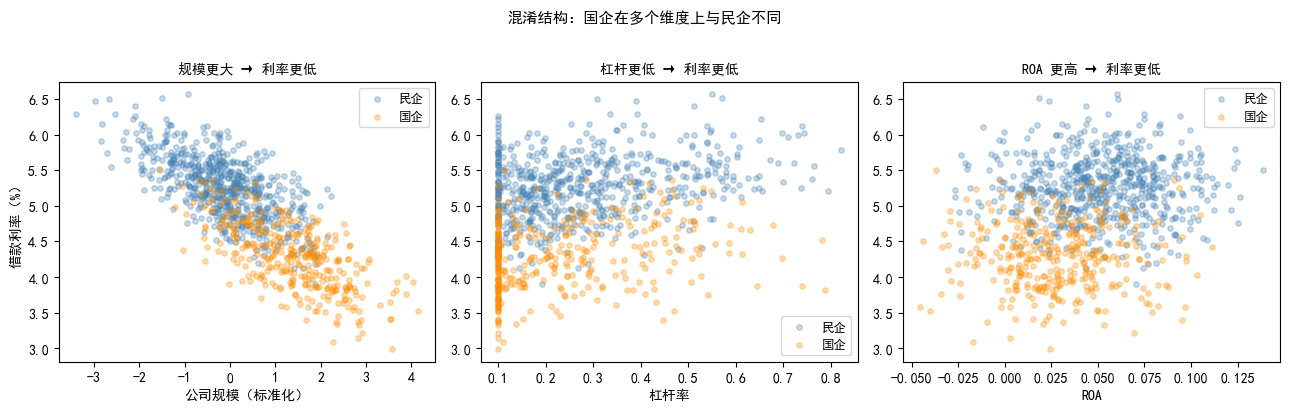

In [8]:
# ── 2.4  可视化：混淆结构 ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

pairs = [
    ('Size_w',     '公司规模（标准化）', '规模更大 → 利率更低'),
    ('Leverage_w', '杠杆率',           '杠杆更低 → 利率更低'),
    ('ROA_w',      'ROA',              'ROA 更高 → 利率更低'),
]

colors = {0: 'steelblue', 1: 'darkorange'}
labels = {0: '民企', 1: '国企'}

for ax, (xcol, xlabel, note) in zip(axes, pairs):
    if xcol not in df.columns:
        ax.set_visible(False)
        continue
    for g in [0, 1]:
        sub = df[df['soe']==g]
        ax.scatter(sub[xcol], sub['avg_loan_rate'],
                   alpha=0.3, s=15, color=colors[g], label=labels[g])
    ax.set_xlabel(xlabel, fontsize=10)
    ax.set_ylabel('借款利率（%）' if ax == axes[0] else '')
    ax.set_title(note, fontsize=10)
    ax.legend(fontsize=9)

plt.suptitle('混淆结构：国企在多个维度上与民企不同', fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig(f'{OUTPUT}/ch05_confounding.png', dpi=150, bbox_inches='tight')
plt.show()


---

## 3　条件期望函数（CEF）与线性回归

### 3.1　CEF 是什么

**条件期望函数（Conditional Expectation Function）** 定义为：

$$\mu(x) = E[Y_i \mid X_i = x]$$

它回答的问题是：**在 $X_i = x$ 的所有个体中，$Y$ 的平均值是多少？**

CEF 是所有预测函数里均方误差最小的那个——
无论 $Y$ 和 $X$ 之间的真实关系多复杂，CEF 都是最优预测。

### 3.2　线性回归作为 CEF 的最佳线性近似

当 CEF 本身不是线性的（在实践中经常如此），OLS 回归给出的是 CEF 的**最佳线性近似（Best Linear Predictor）**：

$$\hat{\beta} = \arg\min_b E[(Y_i - X_i'b)^2]$$

这里有一个关键的认知转变：

::: {.callout-important}
## OLS 不需要「真实模型是线性的」假设

OLS 的系数估计的是 CEF 的最佳线性近似，**不需要假设数据生成过程（DGP）真的是线性的**。

即使真实关系是非线性的，OLS 系数也有清晰的含义：「在线性函数族里，这是最接近 CEF 的那个。」
:::

### 3.3　回归系数的两种解释

- **解释一（描述性）**：控制 $X_2$ 后，$X_1$ 每增加一单位，$Y$ 的期望值变化 $\hat{\beta}_1$。

- **解释二（因果性）**：把 $X_1$ 从外部干预（而非自然变化）增加一单位，$Y$ 会变化多少？

只要满足 OLS 的基本假设，解释一就是成立的。然而，解释二需要额外条件：所有影响 $Y$ 的变量，要么被控制在 $X$ 里，
要么与 $X_1$ 无关（条件独立性假设）。这个条件通常无法直接验证，需要结合研究设计来判断。


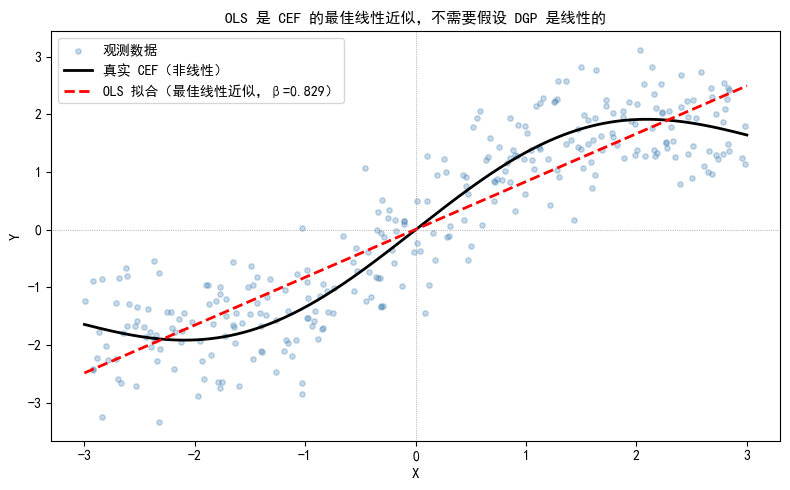

In [9]:
# ── 3.4  直观演示：CEF 是非线性的，OLS 是它的最佳线性近似 ──────────────
x = np.linspace(-3, 3, 500)
# 真实 CEF（非线性）
cef_true = np.sin(x) + 0.5 * x
# 加噪声的观测数据
x_obs = RNG.uniform(-3, 3, 300)
y_obs = np.sin(x_obs) + 0.5 * x_obs + RNG.normal(0, 0.6, 300)

# OLS 拟合
slope, intercept, *_ = stats.linregress(x_obs, y_obs)
ols_line = intercept + slope * x

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(x_obs, y_obs, alpha=0.3, s=15, color='steelblue', label='观测数据')
ax.plot(x, cef_true, 'k-', linewidth=2, label='真实 CEF（非线性）')
ax.plot(x, ols_line, 'r--', linewidth=2,
        label=f'OLS 拟合（最佳线性近似，β={slope:.3f}）')
ax.set_xlabel('X', fontsize=11)
ax.set_ylabel('Y', fontsize=11)
ax.set_title('OLS 是 CEF 的最佳线性近似，不需要假设 DGP 是线性的', fontsize=11)
ax.legend(fontsize=10)
ax.axhline(0, color='gray', linewidth=0.5, linestyle=':')
ax.axvline(0, color='gray', linewidth=0.5, linestyle=':')
plt.tight_layout()
plt.savefig(f'{OUTPUT}/ch05_cef_ols.png', dpi=150, bbox_inches='tight')
plt.show()


---

## 4　FWL 定理：控制变量究竟在做什么

### 4.1　定理陈述

**Frisch-Waugh-Lovell（FWL）定理** 是理解多元回归最重要的工具。

考虑多元回归：

$$Y = \beta_1 X_1 + X_2 \gamma + \varepsilon$$

其中 $X_2$ 是一组控制变量。FWL 定理说：

**$\hat{\beta}_1$ 等于以下双变量回归的斜率：**
1. 将 $Y$ 对 $X_2$ 回归，取残差 $\tilde{Y}$
2. 将 $X_1$ 对 $X_2$ 回归，取残差 $\tilde{X}_1$
3. 将 $\tilde{Y}$ 对 $\tilde{X}_1$ 做简单回归

### 4.2　FWL 的直觉

**残差化（partialling out）**：
- $\tilde{Y}$ 是「去掉 $X_2$ 的影响后，$Y$ 里剩下的变动」
- $\tilde{X}_1$ 是「去掉 $X_2$ 的影响后，$X_1$ 里剩下的变动」
- $\hat{\beta}_1$ 捕捉的是：**在 $X_2$ 已经被控制的情况下，$X_1$ 和 $Y$ 之间还剩多少关系**

换句话说：**多元回归中某变量的系数，就是「净化掉其他控制变量影响后」的偏效应。**

::: {.callout-important}
## FWL 的三个推论（全书反复用到）

**推论 1（固定效应 = FWL 的特例）**：
加入个体固定效应虚拟变量，等价于先对每个个体做组内去均值（demeaning），
再对去均值后的变量做 OLS——这正是 FWL。

**推论 2（DID 的识别逻辑）**：
DID 的处理效应估计量，是在控制了个体 FE 和时间 FE 之后，
处理变量与结果变量之间的残差相关——也是 FWL。

**推论 3（DDML 的核心思想）**：
用机器学习分别残差化 $Y$ 和 $X_1$，再做简单回归——
这是 Double/Debiased ML，本质上还是 FWL，只是用 ML 代替线性回归做残差化。
:::


In [ ]:
# ── 4.3  FWL 定理的 Python 验证 ─────────────────────────────────────────
# 命题：多元回归中 soe 的系数 = 手动残差化后双变量回归的斜率

controls = ['Size_w', 'Leverage_w', 'ROA_w']
avail    = [c for c in controls if c in df.columns]

formula_full = 'avg_loan_rate ~ soe + ' + ' + '.join(avail)

# ── 方法一：直接多元回归 ─────────────────────────────────────────────────
m_full = smf.ols(formula_full, data=df).fit()
beta_direct = m_full.params['soe']

# ── 方法二：FWL 手动三步 ─────────────────────────────────────────────────
# Step 1：Y 对控制变量回归，取残差
m_y = smf.ols('avg_loan_rate ~ ' + ' + '.join(avail), data=df).fit()
y_tilde = m_y.resid

# Step 2：X1（soe）对控制变量回归，取残差
m_x = smf.ols('soe ~ ' + ' + '.join(avail), data=df).fit()
x_tilde = m_x.resid

# Step 3：y_tilde 对 x_tilde 双变量回归
m_fwl = sm.OLS(y_tilde, sm.add_constant(x_tilde)).fit()
beta_fwl = m_fwl.params.iloc[1]

print('FWL 定理验证')
print(f'  方法一（直接多元回归）：soe 系数 = {beta_direct:.6f}')
print(f'  方法二（FWL 三步法）  ：soe 系数 = {beta_fwl:.6f}')
print(f'  差值（应接近零）      ：{abs(beta_direct - beta_fwl):.2e}')
print()
print('结论：两种方法完全一致，FWL 定理得证 ✓')


In [ ]:
# ── 4.4  可视化：FWL 残差散点图 ──────────────────────────────────────────
# 这张图是本章最重要的图——它直观展示了「控制变量后」soe 和利率的净关系

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ── 左图：原始数据（未控制混淆变量）────────────────────────────────────
ax = axes[0]
for g, (label, color) in enumerate([("民企","steelblue"),("国企","darkorange")]):
    sub = df[df['soe']==g]
    ax.scatter(sub['soe'] + RNG.normal(0, 0.03, len(sub)),
               sub['avg_loan_rate'],
               alpha=0.3, s=15, color=color, label=label)
mean_by_soe = df.groupby('soe')['avg_loan_rate'].mean()
ax.plot([0, 1], [mean_by_soe[0], mean_by_soe[1]],
        'k-o', linewidth=2, markersize=8, zorder=5)
ax.annotate(f'差值 = {mean_by_soe[1]-mean_by_soe[0]:.3f}%',
            xy=(0.5, mean_by_soe.mean()), ha='center', fontsize=10,
            xytext=(0, 15), textcoords='offset points')
ax.set_xticks([0, 1])
ax.set_xticklabels(['民企 (soe=0)', '国企 (soe=1)'])
ax.set_ylabel('借款利率（%）')
ax.set_title('原始比较（含混淆变量影响）', fontsize=11)
ax.legend(fontsize=9)

# ── 右图：FWL 残差（净化混淆变量后）────────────────────────────────────
ax = axes[1]
soe_bin = (x_tilde > 0).astype(int)  # 残差 > 0 类似「相对更像国企」
ax.scatter(x_tilde, y_tilde, alpha=0.3, s=15,
           c=["darkorange" if s > 0 else "steelblue" for s in x_tilde])
# 拟合线
x_line = np.linspace(x_tilde.min(), x_tilde.max(), 100)
y_line = beta_fwl * x_line + m_fwl.params.iloc[0]
ax.plot(x_line, y_line, 'r-', linewidth=2,
        label=f'斜率 = {beta_fwl:.3f}（FWL 系数）')
ax.axhline(0, color='gray', linewidth=0.5, linestyle=':')
ax.axvline(0, color='gray', linewidth=0.5, linestyle=':')
ax.set_xlabel('soe 的残差（$\\tilde{X}_1$）', fontsize=10)
ax.set_ylabel('利率的残差（$\\tilde{Y}$）', fontsize=10)
ax.set_title('FWL 净化后：soe 对利率的偏效应', fontsize=11)
ax.legend(fontsize=9)

plt.suptitle('FWL 定理：控制混淆变量前后的对比', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(f'{OUTPUT}/ch05_fwl_visual.png', dpi=150, bbox_inches='tight')
plt.show()


::: {.callout-tip}
## 提示词示范（FWL 验证）

````
我想验证 FWL（Frisch-Waugh-Lovell）定理：
多元回归中变量 X1 的系数，等于手动残差化后双变量回归的斜率。

我的 DataFrame 名为 df，结果变量为 Y，
感兴趣的变量为 X1，控制变量为 X2_list = ['X2', 'X3', 'X4']。

请帮我：
1. 做完整的多元 OLS 回归，记录 X1 的系数
2. 手动执行 FWL 三步（Y 残差化 → X1 残差化 → 双变量回归）
3. 比较两个系数是否一致（差值应 < 1e-10）
4. 绘制 FWL 残差散点图（横轴：X1 残差，纵轴：Y 残差，附拟合线）
````
:::


---

## 5　虚拟变量与交乘项

### 5.1　虚拟变量 = 分组均值差的回归表达

当解释变量是 0/1 的虚拟变量时，回归系数有非常直接的解读：

$$Y_i = \alpha + \beta D_i + \varepsilon_i$$

$\hat{\beta}$ = $D_i = 1$ 组的均值 $-$ $D_i = 0$ 组的均值。

加入控制变量后：

$$Y_i = \alpha + \beta D_i + X_i'\gamma + \varepsilon_i$$

$\hat{\beta}$ = **在 $X$ 相同的个体中**，$D = 1$ 组 vs $D = 0$ 组的均值差。
（由 FWL 定理保证。）

### 5.2　多类别虚拟变量的陷阱

如果 $D$ 有 $k$ 个类别，需要创建 $k-1$ 个虚拟变量，丢掉一个作为**基准组**。
如果创建了 $k$ 个并全部放入回归，会因完全多重共线性导致矩阵不可逆，
statsmodels 会自动删掉一列，但这往往不是你希望的基准组。

### 5.3　交乘项：异质性处理效应

**交乘项**（interaction term）回答的问题是：
**「$X_1$ 对 $Y$ 的影响，是否随 $X_2$ 的不同而不同？」**

$$Y_i = \alpha + \beta_1 X_{1i} + \beta_2 X_{2i} + \beta_3 (X_{1i} \times X_{2i}) + \varepsilon_i$$

- $\hat{\beta}_1$：当 $X_2 = 0$ 时，$X_1$ 的边际效应
- $\hat{\beta}_3$：$X_1$ 的效应随 $X_2$ 每增加一单位的变化量（**异质性**）
- 当 $X_2 = c$ 时，$X_1$ 的完整边际效应 = $\hat{\beta}_1 + \hat{\beta}_3 \cdot c$

::: {.callout-warning}
## 交乘项的常见误读

加入交乘项 $D \times X$ 后，**$D$ 和 $X$ 的主效应系数的解释都会改变**：
它们不再是「平均边际效应」，而是「当交乘的另一个变量为 0 时的边际效应」。

如果 $X$ 的均值不是 0（例如公司规模），应该先**中心化**（减去均值）
再做交乘，让主效应系数有「在均值处」的直觉含义。
:::


In [ ]:
# ── 5.4  虚拟变量 + 交乘项实例：国企效应是否随公司规模变化 ────────────

# 中心化 Size_w（让主效应在均值处有意义）
if 'Size_w' in df.columns:
    df['Size_c'] = df['Size_w'] - df['Size_w'].mean()   # 中心化
    df['soe_x_size'] = df['soe'] * df['Size_c']

    # 模型一：无交乘项
    m1 = smf.ols('avg_loan_rate ~ soe + Size_c + Leverage_w + ROA_w', data=df).fit()

    # 模型二：加入交乘项（soe × Size）
    m2 = smf.ols('avg_loan_rate ~ soe + Size_c + Leverage_w + ROA_w + soe_x_size',
                  data=df).fit()

    print('模型一（无交乘项）：soe 系数 =', round(m1.params['soe'], 4))
    print()
    print('模型二（有交乘项 soe × Size_c）：')
    print(f'  soe 主效应（Size=均值时）：{m2.params["soe"]:.3f}')
    print(f'  soe × Size_c 系数        ：{m2.params["soe_x_size"]:.3f}')
    print(f'  → 规模每增加 1 个标准差，国企效应变化：{m2.params["soe_x_size"]:.3f}%')


In [ ]:
# ── 5.5  可视化：国企利率优势随规模的变化 ──────────────────────────────
if 'Size_w' in df.columns:
    beta_soe   = m2.params['soe']
    beta_inter = m2.params['soe_x_size']

    size_range = np.linspace(df['Size_c'].min(), df['Size_c'].max(), 100)
    soe_effect = beta_soe + beta_inter * size_range  # 边际效应随 Size 变化

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(size_range + df['Size_w'].mean(),   # 转回原始规模水平
            soe_effect, color='steelblue', linewidth=2)
    ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')
    ax.fill_between(size_range + df['Size_w'].mean(),
                    soe_effect, 0,
                    where=soe_effect < 0, alpha=0.15, color='steelblue',
                    label='国企利率更低（利率优势）')
    ax.fill_between(size_range + df['Size_w'].mean(),
                    soe_effect, 0,
                    where=soe_effect > 0, alpha=0.15, color='red',
                    label='国企利率更高（规模惩罚？）')
    ax.set_xlabel('公司规模（ln 总资产）', fontsize=11)
    ax.set_ylabel('国企 vs 民企 利率差（%）', fontsize=11)
    ax.set_title('国企利率优势随公司规模的变化（含交乘项）', fontsize=11)
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.savefig(f'{OUTPUT}/ch05_interaction.png', dpi=150, bbox_inches='tight')
    plt.show()


::: {.callout-tip}
## 提示词示范（交乘项）

````
我想分析：国企效应（soe 对借款利率的影响）是否随公司规模（Size_w）而变化。
DataFrame 名为 df，结果变量为 avg_loan_rate。

请帮我：
1. 先对 Size_w 做中心化处理（减去均值），命名为 Size_c
2. 做两个模型：无交乘项 vs 有交乘项（soe × Size_c）
3. 解释交乘项系数的含义
4. 计算并绘制「国企效应随规模变化」的边际效应图，
   横轴为 Size_w 的实际值，纵轴为国企系数，加 95% 置信带
````
:::


---

## 6　聚类标准误

### 6.1　为什么需要聚类标准误

OLS 的标准误公式假设扰动项 $\varepsilon_i$ 之间相互独立。
但在金融面板数据中，这个假设几乎从不成立：
同一家公司不同年份的扰动项（比如管理层风格、行业冲击）高度相关；
同一年份不同公司的扰动项（宏观冲击）也可能相关。

如果不处理这种**组内相关（within-cluster correlation）**，
OLS 标准误会被**严重低估**，$t$ 值虚高，显著性检验失去意义。

**聚类标准误（Clustered Standard Errors）**在组（cluster）层面允许任意相关，
只要不同组之间独立，标准误就是一致的。

### 6.2　按哪一层聚类

::: {.callout-important}
## 聚类层级选择原则：按处理变量的分配单元

聚类的层级应该和**处理变量的分配单元**一致，而不是观测单位。

| 研究场景 | 处理变量 | 聚类层级 |
|----------|----------|----------|
| 公司面板，关心公司特征的效应 | `soe`（公司层面）| 按公司（`stkcd`）聚类 |
| 省级政策冲击，公司面板 | 省级政策 | 按省（`province`）聚类 |
| 行业冲击，公司面板 | 行业特征 | 按行业（`industry`）聚类 |

如果不确定，**聚类层级宁高勿低**——
按更高层级聚类（如行业）比按更低层级（如公司）更保守，
不会产生虚假显著性。
:::


In [ ]:
# ── 6.3  不同标准误的对比 ────────────────────────────────────────────────
# 演示：OLS / 异方差稳健 / 公司聚类 三种标准误的差异

formula = 'avg_loan_rate ~ soe + Size_w + Leverage_w + ROA_w'
m_base = smf.ols(formula, data=df).fit()

# 方法一：普通 OLS 标准误
se_ols = m_base.bse['soe']
t_ols  = m_base.tvalues['soe']

# 方法二：HC1 异方差稳健标准误（White robust）
m_hc1 = m_base.get_robustcov_results(cov_type='HC1')
se_hc1 = m_hc1.bse['soe']
t_hc1  = m_hc1.tvalues['soe']

# 方法三：公司层面聚类标准误
m_clust = m_base.get_robustcov_results(
    cov_type='cluster',
    groups=df['stkcd']
)
se_clust = m_clust.bse['soe']
t_clust  = m_clust.tvalues['soe']

print('soe 系数的不同标准误对比：')
print(f'  系数值（三种方法相同）：{m_base.params["soe"]:.3f}')
print(f'  {'标准误类型':<20} {'SE':>8} {'t值':>8} {'是否显著(5%)':>12}')
print('  ' + '─' * 52)
for label, se, t in [
    ('OLS（假设同方差）', se_ols, t_ols),
    ('HC1（异方差稳健）', se_hc1, t_hc1),
    ('公司聚类', se_clust, t_clust),
]:
    sig = '✓' if abs(t) > 1.96 else '✗'
    print(f'  {label:<20} {se:>8.3f} {t:>8.3f} {sig:>12}')

print()
print('注意：聚类标准误通常比 OLS SE 大（有时大很多），',
      '反映了组内相关对有效样本量的压缩。')


---

## 7　规范呈现回归结果

实证论文和行业研究报告对回归表格有一套约定俗成的格式。
本节演示如何用 `pyfixest`（Python）和 Stata `esttab` 生成符合规范的表格。

**标准回归表应包含：**
- 系数（coefficient）
- 标准误（standard error）或 $t$ 值，放在系数下方括号里
- 显著性星号（\* $p < 0.1$，\*\* $p < 0.05$，\*\*\* $p < 0.01$）
- 样本量 $N$、$R^2$、调整 $R^2$
- 固定效应设置（Yes/No）
- 标准误类型（脚注说明）


In [ ]:
# ── 7.1  pyfixest 多模型并排输出 ─────────────────────────────────────────
# 三个递进模型：裸回归 → 加控制变量 → 加年份固定效应

m1 = pf.feols('avg_loan_rate ~ soe',
              data=df, vcov={'CRV1': 'stkcd'})

m2 = pf.feols('avg_loan_rate ~ soe + Size_w + Leverage_w + ROA_w',
              data=df, vcov={'CRV1': 'stkcd'})

m3 = pf.feols('avg_loan_rate ~ soe + Size_w + Leverage_w + ROA_w | year',
              data=df, vcov={'CRV1': 'stkcd'})

# etable 输出（等价于 Stata esttab）
pf.etable(
    [m1, m2, m3],
    coef_fmt = 'b\n(se)',   # 系数换行后接括号里的标准误
    digits   = 3,
    stars    = True,
    labels   = {
        'avg_loan_rate': '借款利率（%）',
        'soe'  : '国企（=1）',
        'Size_w': '公司规模',
        'Leverage_w': '杠杆率',
        'ROA_w': 'ROA',
    }
)


**等价的 Stata 代码（供参考）：**

```stata
* ── 在 Jupyter 里用 %%stata 运行（需配置 pystata，见第 2 章）────────────
use "data_clean/merged_clean.dta", clear

* 模型一：裸回归
reg avg_loan_rate soe, vce(cluster stkcd)
est store m1

* 模型二：加控制变量
reg avg_loan_rate soe Size_w Leverage_w ROA_w, vce(cluster stkcd)
est store m2

* 模型三：加年份固定效应（需要安装 reghdfe：ssc install reghdfe）
reghdfe avg_loan_rate soe Size_w Leverage_w ROA_w, ///
    absorb(year) vce(cluster stkcd)
est store m3

* 输出回归表（需要安装 estout：ssc install estout）
esttab m1 m2 m3, ///
    star(* 0.1 ** 0.05 *** 0.01) ///
    se b(%9.3f) r2 scalars(N) ///
    mtitles("裸回归" "加控制" "年份FE") ///
    label
```

::: {.callout-tip}
## 提示词模板：pyfixest 多模型回归表

这是全书回归部分最常用的提示词模板，每次做回归分析都可以套用：

````
我有一个面板 DataFrame df，列为 firm, year 以及若干财务变量。
结果变量：Y。感兴趣变量：D（0/1 虚拟变量）。控制变量：X1, X2, X3。

请用 pyfixest 帮我做三个递进模型，标准误均采用公司层面聚类：
- 模型 1：OLS，无控制变量，无固定效应
- 模型 2：OLS，加控制变量，无固定效应
- 模型 3：TWFE，加控制变量，公司 + 年份双向固定效应

输出要求：
- pf.etable 并排展示三列，系数下接括号标准误
- 显著性星号：* 0.1, ** 0.05, *** 0.01
- 表格下方注明固定效应设置（Yes/No）和标准误类型
- 同时给出等价的 Stata 代码（reg/reghdfe + esttab）
````
:::


---

## 8　综合案例：国企借款利率优势的完整分析

把本章所有工具串联，对「国企借款利率优势」做一次完整的回归分析。
这个分析也是第四次个人作业（T3 作业）的参考模板。


In [ ]:
# ── 8.1  完整分析流程 ────────────────────────────────────────────────────

print('=' * 60)
print(f'数据来源：{DATA_SOURCE}')
print(f'样本：{df["stkcd"].nunique()} 家公司，{df["year"].nunique()} 年，{len(df)} 个观测')
print('=' * 60)

# ── Step 1：描述统计 ─────────────────────────────────────────────────────
print('\n── Step 1：描述统计 ──────────────────────────────────────────────')
desc_cols = ['avg_loan_rate','soe','Size_w','Leverage_w','ROA_w']
avail_desc = [c for c in desc_cols if c in df.columns]
print(df[avail_desc].describe().round(3).to_string())

# ── Step 2：单变量检验（$t$ 检验）──────────────────────────────────────
print('\n── Step 2：均值差异 t 检验 ───────────────────────────────────────')
r1 = df[df['soe']==1]['avg_loan_rate']
r0 = df[df['soe']==0]['avg_loan_rate']
t_stat, p_val = stats.ttest_ind(r1, r0)
print(f'国企均值：{r1.mean():.3f}%  民企均值：{r0.mean():.3f}%')
print(f'差值：{r1.mean()-r0.mean():.3f}%  t={t_stat:.3f}  p={p_val:.3f}')
print('（注：此为简单比较，未控制任何混淆变量）')


In [ ]:
# ── Step 3：递进回归（pyfixest）─────────────────────────────────────────
print('\n── Step 3：递进回归 ──────────────────────────────────────────────')

base_controls = [c for c in ['Size_w','Leverage_w','ROA_w'] if c in df.columns]
ctrl_str = ' + '.join(base_controls)

reg_m1 = pf.feols(f'avg_loan_rate ~ soe',
                   data=df, vcov={'CRV1': 'stkcd'})

reg_m2 = pf.feols(f'avg_loan_rate ~ soe + {ctrl_str}',
                   data=df, vcov={'CRV1': 'stkcd'})

reg_m3 = pf.feols(f'avg_loan_rate ~ soe + {ctrl_str} | year',
                   data=df, vcov={'CRV1': 'stkcd'})

reg_m4 = pf.feols(f'avg_loan_rate ~ soe + {ctrl_str} | stkcd + year',
                   data=df, vcov={'CRV1': 'stkcd'})

pf.etable(
    [reg_m1, reg_m2, reg_m3, reg_m4],
    coef_fmt='b\n(se)', digits=3, stars=True,
    labels={'avg_loan_rate': '借款利率（%）', 'soe': '国企（=1）',
            'Size_w': '规模', 'Leverage_w': '杠杆', 'ROA_w': 'ROA'}
)


In [ ]:
# ── Step 4：FWL 验证最终模型（双向 FE + 控制变量）──────────────────────
print('\n── Step 4：FWL 验证（双向 FE 模型）──────────────────────────────')

# 在 pyfixest 里，双向 FE 内部用 FWL（Mundlak demeaning）实现
# 我们手动验证：公司 + 年份去均值后，soe 的系数应与模型四一致

df_dem = df.copy()
for col in ['avg_loan_rate', 'soe'] + base_controls:
    firm_mean = df_dem.groupby('stkcd')[col].transform('mean')
    year_mean = df_dem.groupby('year')[col].transform('mean')
    grand_mean = df_dem[col].mean()
    # 双向去均值（近似，精确版需迭代）
    df_dem[f'{col}_dem'] = df_dem[col] - firm_mean - year_mean + grand_mean

ctrl_dem = ' + '.join([f'{c}_dem' for c in base_controls])
m_dem = smf.ols(f'avg_loan_rate_dem ~ soe_dem + {ctrl_dem}', data=df_dem).fit()

coef_pf   = reg_m4.coef()['soe']
coef_dem  = m_dem.params['soe_dem']
print(f'pyfixest 双向 FE 系数  ：{coef_pf:.6f}')
print(f'手动双向去均值 OLS 系数：{coef_dem:.6f}')
print(f'差值（应接近零）       ：{abs(coef_pf - coef_dem):.2e}')
print('（小差异来自双向去均值的迭代近似，pyfixest 使用精确迭代算法）')


In [ ]:
# ── Step 5：结论与解读 ───────────────────────────────────────────────────
soe_m1 = reg_m1.coef()['soe']
soe_m4 = reg_m4.coef()['soe']
pct_change = (soe_m4 - soe_m1) / abs(soe_m1) * 100

print('\n── Step 5：分析结论 ──────────────────────────────────────────────')
print(f'模型一（无控制变量）soe 系数：{soe_m1:.3f}%')
print(f'模型四（双向 FE + 控制变量）soe 系数：{soe_m4:.3f}%')
print(f'加入控制变量后系数变化：{pct_change:+.1f}%')
print()
print('解读：')
print('1. 简单比较（模型一）：国企利率比民企低约', f'{soe_m1:.2f}%')
print('   这里混入了规模、杠杆率等混淆变量的影响。')
print('2. 控制混淆变量后（模型四）：系数变化说明多少是混淆，多少是净效应。')
if DATA_SOURCE == '模拟数据（DGP 已知）':
    print('   真实系数为 -0.5%，模型四的估计接近该值 ✓')
print('3. 即使控制后仍显著，也不能断言「因果」——',
      '可能仍有遗漏变量。要做因果推断需要 DID 或 IV（见第 8 章）。')


---

## 9　章末练习

**练习 1（FWL 验证）**
选择一个控制变量（如 `Leverage_w`），手动执行 FWL 三步法，
验证其系数与直接多元回归完全一致。
绘制该变量的 FWL 残差散点图，并写一句话解释斜率的含义。

**练习 2（交乘项）**
探究国企利率优势是否随行业（`industry`，若数据中有此列）而变化。
构造 `soe × industry` 交乘项，输出回归结果，
绘制各行业国企系数的系数图（点估计 + 95% 置信区间）。

**练习 3（标准误对比）**
对同一个回归模型，分别使用 OLS SE、HC1 SE、
公司聚类 SE、年份聚类 SE，
输出四种标准误的对比表，并回答：
- 哪种标准误最小？哪种最大？为什么？
- 在本研究场景中，你认为应该用哪种？

**练习 4（思考题）**
假设你在模型四中发现国企系数在 1% 水平下显著为负（$p < 0.01$）。
一位朋友说：「这证明了国企身份导致了更低的融资成本，
说明国企在信贷市场上享有特殊优惠。」
你如何评价这个结论？
用本章的概念（潜在结果、选择性偏误、CEF vs 因果）写出你的分析（200 字以内）。
